In [1]:
# Download NLTK data
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger_eng')
 
print("✅ All dependencies installed and ready!")

✅ All dependencies installed and ready!


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\rajen\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [2]:
# ── Core libraries ──────────────────────────────────────────────
import requests
import json
import re
import time
from datetime import datetime
 
# ── Data handling ────────────────────────────────────────────────
import pandas as pd
 
# ── NLP ──────────────────────────────────────────────────────────
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist
 
# Sentiment Analysis
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
 
# ── Web Scraping ─────────────────────────────────────────────────
from bs4 import BeautifulSoup
 
# ── Visualization ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
 
print("✅ All imports successful!")
 

✅ All imports successful!


In [5]:
NEWS_API_KEY = "f7c896df47ad42e295d554715d55a551"
CATEGORIES = ["technology", "business"]
SEARCH_QUERIES = ["economy", "artificial intelligence"]
PAGE_SIZE = 1
COUNTRY ="us"
BASE_URL = "https://newsapi.org/v2"

In [3]:
all_articles = []
 

In [6]:
def fetch_top_headlines(category:str, country:str, page_size:int=PAGE_SIZE) -> list:
    url = f"{BASE_URL}/top-headlines"
    print(url)
    request = {
        "apiKey" : NEWS_API_KEY,
        "category": category,
        "country": country,
        "pageSize" : page_size
    }
    print(request)
   
    response = requests.get(url, params=request, timeout=10)
    print(response)
    if(response.status_code != 200):
        print(f" API error {response.status_code}")
   
    articles = response.json().get('articles', [])
    print(articles)
    return articles
 
for cat in CATEGORIES:
    articles = fetch_top_headlines(category=cat, country=COUNTRY)
    for art in articles:
        art["query_category"] = cat
    all_articles.extend(articles)
 
print(all_articles)

https://newsapi.org/v2/top-headlines
{'apiKey': 'f7c896df47ad42e295d554715d55a551', 'category': 'technology', 'country': 'us', 'pageSize': 1}
<Response [200]>
[{'source': {'id': None, 'name': 'Nintendoeverything.com'}, 'author': 'Brian', 'title': 'Mario Kart World 1.6.1 update out now, patch notes - Nintendo Everything', 'description': 'Mario Kart World just received a new version 1.6.1 update from Nintendo, and you can get the patch notes here.', 'url': 'https://nintendoeverything.com/mario-kart-world-1-6-1-update-out-now-patch-notes/', 'urlToImage': 'https://nintendoeverything.com/wp-content/uploads/Mario-Kart-World-1.6.1-update.jpg', 'publishedAt': '2026-04-10T01:06:45Z', 'content': 'Nintendo is back with another update for Mario Kart World, bringing the game up to version 1.6.1.\r\nThis patch is about bug fixes, so there aren’t any new additions here. Nintendo addressed two specif… [+776 chars]'}]
https://newsapi.org/v2/top-headlines
{'apiKey': 'f7c896df47ad42e295d554715d55a551', '

In [7]:
def fetch_by_keyword(query:str, page_size:int=PAGE_SIZE) -> list:
    url = f"{BASE_URL}/everything"
    print(url)
    request = {
        "apiKey" : NEWS_API_KEY,
        "q": query,
        "language": "en",
        "sortBy": "publishedAt",
        "pageSize": page_size
    }
    print(request)
   
    response = requests.get(url, params=request, timeout=10)
    print(response)
    if(response.status_code != 200):
        print(f" API error {response.status_code}")
   
    articles = response.json().get('articles', [])
    print(articles)
    return articles
 
for query in SEARCH_QUERIES:
    articles = fetch_by_keyword(query=query)
    for art in articles:
        art["query_category"] = f"kw:{query}"
    all_articles.extend(articles)

https://newsapi.org/v2/everything
{'apiKey': 'f7c896df47ad42e295d554715d55a551', 'q': 'economy', 'language': 'en', 'sortBy': 'publishedAt', 'pageSize': 1}
<Response [200]>
[{'source': {'id': 'financial-post', 'name': 'Financial Post'}, 'author': 'Bloomberg News', 'title': 'Xi’s $270 Billion Middle East Bet Limits China Support for Iran', 'description': 'Even as China remains one of Iran’s biggest diplomatic allies, President Xi Jinping’s support for the Islamic Republic is being constrained by a vast trail of Chinese\xa0capital across the Gulf.\xa0\xa0China ramped up investment in the\xa0Middle East in the wake of the p…', 'url': 'https://financialpost.com/pmn/business-pmn/xis-270-billion-middle-east-bet-limits-china-support-for-iran', 'urlToImage': 'https://smartcdn.gprod.postmedia.digital/financialpost/wp-content/uploads/2026/04/china-has-vast-economic-interests-in-the-middle-east-chines.jpg', 'publishedAt': '2026-04-10T04:58:55Z', 'content': 'While no Chinese workers have been repor

In [8]:
print(json.dumps(all_articles, indent=2))

[
  {
    "source": {
      "id": null,
      "name": "Nintendoeverything.com"
    },
    "author": "Brian",
    "title": "Mario Kart World 1.6.1 update out now, patch notes - Nintendo Everything",
    "description": "Mario Kart World just received a new version 1.6.1 update from Nintendo, and you can get the patch notes here.",
    "url": "https://nintendoeverything.com/mario-kart-world-1-6-1-update-out-now-patch-notes/",
    "urlToImage": "https://nintendoeverything.com/wp-content/uploads/Mario-Kart-World-1.6.1-update.jpg",
    "publishedAt": "2026-04-10T01:06:45Z",
    "content": "Nintendo is back with another update for Mario Kart World, bringing the game up to version 1.6.1.\r\nThis patch is about bug fixes, so there aren\u2019t any new additions here. Nintendo addressed two specif\u2026 [+776 chars]",
    "query_category": "technology"
  },
  {
    "source": {
      "id": "politico",
      "name": "Politico"
    },
    "author": "Associated Press",
    "title": "USPS to suspend p

In [10]:
def articles_to_dataframe(articles:list) -> pd.DataFrame:
    rows = []
    for art in articles:
        rows.append({
            "title": art.get("title") or "",
            "description" : art.get("description") or "",
            "source" : art.get("source", {}).get("name") or "Unknown",
            "url": art.get("url") or "",
            "published_at" : art.get("publishedAt") or "",
            "category" : art.get("query_category"),
            "full_text" : " ".join(filter(None, [
                art.get("title") or "",
                art.get("description") or "",
                art.get("content") or ""
            ]))
        })
    df = pd.DataFrame(rows)
    return df
 
df = articles_to_dataframe(all_articles)
df.head()

,title,description,source,url,published_at,category,full_text
0,"Mario Kart World 1.6.1 update out now, patch n...",Mario Kart World just received a new version 1...,Nintendoeverything.com,https://nintendoeverything.com/mario-kart-worl...,2026-04-10T01:06:45Z,technology,"Mario Kart World 1.6.1 update out now, patch n..."
1,"USPS to suspend pension contributions, seeks 4...","If approved by regulators, the price of a firs...",Politico,https://www.politico.com/news/2026/04/09/usps-...,2026-04-10T01:00:00Z,business,"USPS to suspend pension contributions, seeks 4..."
2,Xi’s $270 Billion Middle East Bet Limits China...,Even as China remains one of Iran’s biggest di...,Financial Post,https://financialpost.com/pmn/business-pmn/xis...,2026-04-10T04:58:55Z,kw:economy,Xi’s $270 Billion Middle East Bet Limits China...
3,Chinese startup ShengShu raises $293 million t...,Founded in early 2023 by ​Tsinghua University ...,The Times of India,https://economictimes.indiatimes.com/tech/fund...,2026-04-10T04:55:05Z,kw:artificial intelligence,Chinese startup ShengShu raises $293 million t...


In [11]:
# ── Regex patterns used in this project ─────────────────────────
PATTERNS = {
    "url":         re.compile(r'https?://\S+'),
    #before → "Read more at https://bbc.com/news/article-123 today"
    #after  → "Read more at   today"
    "html_tag":    re.compile(r'<[^>]+>'),
    #before → "<b>BREAKING:</b> Markets <em>fall</em> sharply"
    #after  → " BREAKING:  Markets  fall  sharply"
    "punctuation": re.compile(r'[^a-zA-Z\s]'),
    #before → "Apple stock up 3.4% — best day since 2021!"
    #after  → "Apple stock up      best day since      "
    "extra_space": re.compile(r'\s+'),
    #before → "Apple   stock    up      best   day"
    #after  → "Apple stock up best day"
    "ticker":      re.compile(r'\b[A-Z]{2,5}\b'),          # stock tickers / abbreviations
    #input   → "AAPL and TSLA both rose as NASA announced funding"
    #extracts → ["AAPL", "TSLA", "NASA"]
    "proper_noun": re.compile(r'\b[A-Z][a-z]+(?:\s[A-Z][a-z]+)+'),  # naive NER
    #input    → "Elon Musk met Tim Cook in New York yesterday"
    #extracts → ["Elon Musk", "Tim Cook", "New York"]
    "year":        re.compile(r'\b(19|20)\d{2}\b'),
    #input    → "The 2024 budget follows the 2023 deficit report"
    #extracts → ["2024", "2023"]
    "number":      re.compile(r'\b\d+\.?\d*\b'),
    #input    → "Stocks fell 4.2 points and GDP grew by 1 percent"
    #extracts → ["4.2", "1"]
    "chars_bracket": re.compile(r'\[\+?\d+\s*chars?\]'),   # NewsAPI truncation marker
    #before → "The economy shrank [+247 chars]"
    #after  → "The economy shrank  "
}
 
def clean_text(text: str) -> str:
    """Full regex cleaning pipeline for NLP."""
    text = PATTERNS["html_tag"].sub(' ', text)        # remove HTML tags
    text = PATTERNS["url"].sub(' ', text)             # remove URLs
    text = PATTERNS["chars_bracket"].sub(' ', text)   # remove [+N chars] artifacts
    text = PATTERNS["punctuation"].sub(' ', text)     # remove punctuation/numbers
    text = PATTERNS["extra_space"].sub(' ', text)     # normalize whitespace
    return text.strip().lower()
 
def extract_proper_nouns(text: str) -> list:
    """Extract likely named entities using a regex heuristic."""
    return PATTERNS["proper_noun"].findall(text)
 
 
def extract_tickers(text: str) -> list:
    """Extract stock ticker / acronym candidates."""
    return PATTERNS["ticker"].findall(text)
 
# ── Apply cleaning to the DataFrame ─────────────────────────────
df["clean_text"]    = df["full_text"].apply(clean_text)
df["proper_nouns"]  = df["full_text"].apply(extract_proper_nouns)
df["tickers"]       = df["title"].apply(extract_tickers)
 
# ── Demo: show before vs after cleaning ─────────────────────────
idx = 1
print("ORIGINAL:\n", df['full_text'].iloc[idx][:300])
print("\nCLEANED:\n",  df['clean_text'].iloc[idx][:300])
print("\nPROPER NOUNS FOUND:", df['proper_nouns'].iloc[idx][:5])

ORIGINAL:
 USPS to suspend pension contributions, seeks 4-cent stamp price hike - Politico If approved by regulators, the price of a first-class mail Forever stamp would rise from 78 cents to 82 cents. Despite the suspension of employer contributions, effective Friday, current and future retirees will not be i

CLEANED:
 usps to suspend pension contributions seeks cent stamp price hike politico if approved by regulators the price of a first class mail forever stamp would rise from cents to cents despite the suspension of employer contributions effective friday current and future retirees will not be immediately impa

PROPER NOUNS FOUND: ['Politico If', 'Postal Service']


In [12]:
STOP_WORDS = set(stopwords.words('english'))
print(STOP_WORDS)

{"she'll", 'hadn', 'will', 'once', "it's", 'into', 'you', 'myself', 'very', 'to', 'am', 'ourselves', "she'd", 'here', 'after', "i'm", "couldn't", 'doesn', 'up', 'why', 'mustn', 'weren', "wouldn't", 'out', 'any', "aren't", 'more', 'there', 'a', 'during', 'it', "don't", 'no', 'by', "should've", 'my', 'under', 'had', 'is', 'from', 'before', 's', 'she', 'such', "weren't", 'now', 'but', 'them', 'won', 'yourself', 'other', 'was', 'not', "shan't", "i've", 'yours', 'himself', "hasn't", 'at', 'y', 'their', "he's", "doesn't", 'needn', 'and', 'doing', 'these', 'does', 'they', 'whom', 'about', 'd', 'herself', 'be', 'aren', 'should', 'than', 've', 'which', 're', 'only', "we'd", 'theirs', "won't", 'did', "mustn't", 'as', "i'll", "they've", 'down', 't', "didn't", 'over', 'him', 'too', 'through', 'those', "haven't", 'few', 'hasn', 'll', 'do', 'are', 'same', 'your', 'themselves', 'wasn', "you'd", 'then', 'didn', 'for', 'have', 'hers', 'can', 'm', "we've", 'what', 'how', 'above', 'mightn', 'has', 'while

In [13]:
STOP_WORDS = set(stopwords.words('english'))
# Add domain-specific stopwords
STOP_WORDS.update(['said', 'say', 'says', 'new', 'us', 'also', 'one', 'two',
                   'would', 'could', 'may', 'will', 'get', 'got', 'year',
                   'first', 'last', 'week', 'day', 'time', 'report'])
print(STOP_WORDS)

{"she'll", 'hadn', 'will', 'once', "it's", 'into', 'one', 'you', 'myself', 'very', 'to', 'am', 'ourselves', "she'd", 'here', 'after', "i'm", "couldn't", 'doesn', 'up', 'why', 'mustn', 'weren', "wouldn't", 'out', 'any', "aren't", 'more', 'there', 'a', 'during', 'it', "don't", 'no', 'by', "should've", 'my', 'under', 'day', 'had', 'is', 'from', 'before', 's', 'she', 'such', "weren't", 'now', 'but', 'them', 'won', 'yourself', 'other', 'was', 'not', "shan't", "i've", 'week', 'yours', 'himself', "hasn't", 'at', 'y', 'their', "he's", "doesn't", 'needn', 'and', 'doing', 'these', 'does', 'they', 'whom', 'said', 'about', 'would', 'd', 'herself', 'be', 'aren', 'should', 'than', 've', 'which', 'new', 're', 'only', "we'd", 'theirs', "won't", 'also', 'did', "mustn't", 'as', "i'll", "they've", 'down', 't', "didn't", 'over', 'him', 'too', 'through', 'those', "haven't", 'few', 'last', 'hasn', 'll', 'do', 'are', 'same', 'your', 'themselves', 'wasn', "you'd", 'get', 'then', 'two', 'didn', 'say', 'for', '

In [14]:
tokens = word_tokenize('chinese startup shengshu raises million to chinese')
print(tokens)

['chinese', 'startup', 'shengshu', 'raises', 'million', 'to', 'chinese']


In [15]:
def tokenize_and_filter(text: str) -> list:
    """Tokenize text and remove stopwords & short tokens."""
    tokens = word_tokenize(text)                            # split into words
    tokens = [t for t in tokens if t.isalpha()]            # keep only alphabetic
    tokens = [t for t in tokens if t not in STOP_WORDS]    # remove stopwords
    tokens = [t for t in tokens if len(t) > 2]             # remove very short words
    return tokens
 
 
# Apply to all articles
df["tokens"] = df["clean_text"].apply(tokenize_and_filter)
df["token_count"] = df["tokens"].apply(len)
 

In [16]:
df.head()

,title,description,source,url,published_at,category,full_text,clean_text,proper_nouns,tickers,tokens,token_count
0,"Mario Kart World 1.6.1 update out now, patch n...",Mario Kart World just received a new version 1...,Nintendoeverything.com,https://nintendoeverything.com/mario-kart-worl...,2026-04-10T01:06:45Z,technology,"Mario Kart World 1.6.1 update out now, patch n...",mario kart world update out now patch notes ni...,"[Mario Kart World, Nintendo Everything Mario K...",[],"[mario, kart, world, update, patch, notes, nin...",34
1,"USPS to suspend pension contributions, seeks 4...","If approved by regulators, the price of a firs...",Politico,https://www.politico.com/news/2026/04/09/usps-...,2026-04-10T01:00:00Z,business,"USPS to suspend pension contributions, seeks 4...",usps to suspend pension contributions seeks ce...,"[Politico If, Postal Service]",[USPS],"[usps, suspend, pension, contributions, seeks,...",37
2,Xi’s $270 Billion Middle East Bet Limits China...,Even as China remains one of Iran’s biggest di...,Financial Post,https://financialpost.com/pmn/business-pmn/xis...,2026-04-10T04:58:55Z,kw:economy,Xi’s $270 Billion Middle East Bet Limits China...,xi s billion middle east bet limits china supp...,"[Billion Middle East Bet Limits China Support,...",[],"[billion, middle, east, bet, limits, china, su...",51
3,Chinese startup ShengShu raises $293 million t...,Founded in early 2023 by ​Tsinghua University ...,The Times of India,https://economictimes.indiatimes.com/tech/fund...,2026-04-10T04:55:05Z,kw:artificial intelligence,Chinese startup ShengShu raises $293 million t...,chinese startup shengshu raises million to adv...,"[Tsinghua University, Zhu Jun, Alibaba Cloud]",[],"[chinese, startup, shengshu, raises, million, ...",53


In [17]:
# ── Global word frequency across ALL articles ────────────────────
all_tokens = [token for tokens in df["tokens"] for token in tokens]
freq_dist  = FreqDist(all_tokens)
 
print(f"Total tokens (after cleaning): {len(all_tokens):,}")
print(f"Unique tokens: {len(freq_dist):,}")
print("\nTop 20 most frequent words:")
for word, count in freq_dist.most_common(20):
    print(f"  {word:20s} {count:4d}")

Total tokens (after cleaning): 175
Unique tokens: 133

Top 20 most frequent words:
  chinese                 6
  nintendo                4
  mario                   3
  kart                    3
  world                   3
  update                  3
  patch                   3
  china                   3
  iran                    3
  shengshu                3
  company                 3
  notes                   2
  version                 2
  contributions           2
  stamp                   2
  price                   2
  cents                   2
  friday                  2
  billion                 2
  middle                  2


('chinese', 'nintendo', 'mario', 'kart', 'world', 'update', 'patch', 'china', 'iran', 'shengshu', 'company', 'notes', 'version', 'contributions', 'stamp', 'price', 'cents', 'friday', 'billion', 'middle', 'east', 'support', 'startup', 'million', 'artificial') (6, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2)


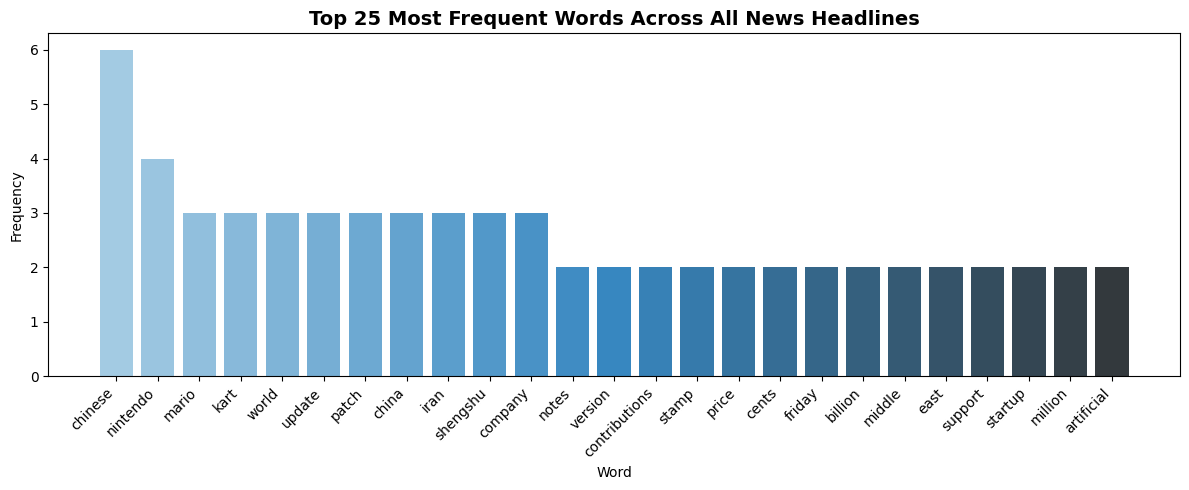

✅ Frequency chart displayed


In [20]:
top_words = freq_dist.most_common(25)
words, counts = zip(*top_words)
print(words, counts)

plt.figure(figsize=(12, 5))
bars = plt.bar(words, counts, color=sns.color_palette("Blues_d", 25))
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title("Top 25 Most Frequent Words Across All News Headlines", fontsize=14, fontweight='bold')
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
print("✅ Frequency chart displayed")

In [41]:
text_for_cloud = " ".join(all_tokens)
print(text_for_cloud)
 

mario kart world update patch notes nintendo everything mario kart world received version update nintendo patch notes nintendo back another update mario kart world bringing game version patch bug fixes additions nintendo addressed specif usps suspend pension contributions seeks cent stamp price hike politico approved regulators price class mail forever stamp rise cents cents despite suspension employer contributions effective friday current future retirees immediately impacted grossman risk postal service american publi billion middle east bet limits china support iran even china remains iran biggest diplomatic allies president jinping support islamic republic constrained vast trail chinese capital across gulf china ramped investment middle east wake chinese workers reported injured outside iran thousands working war zone conflict began chinese citizens stationed united arab emira chinese startup shengshu raises million advance artificial general intelligence founded early tsinghua uni

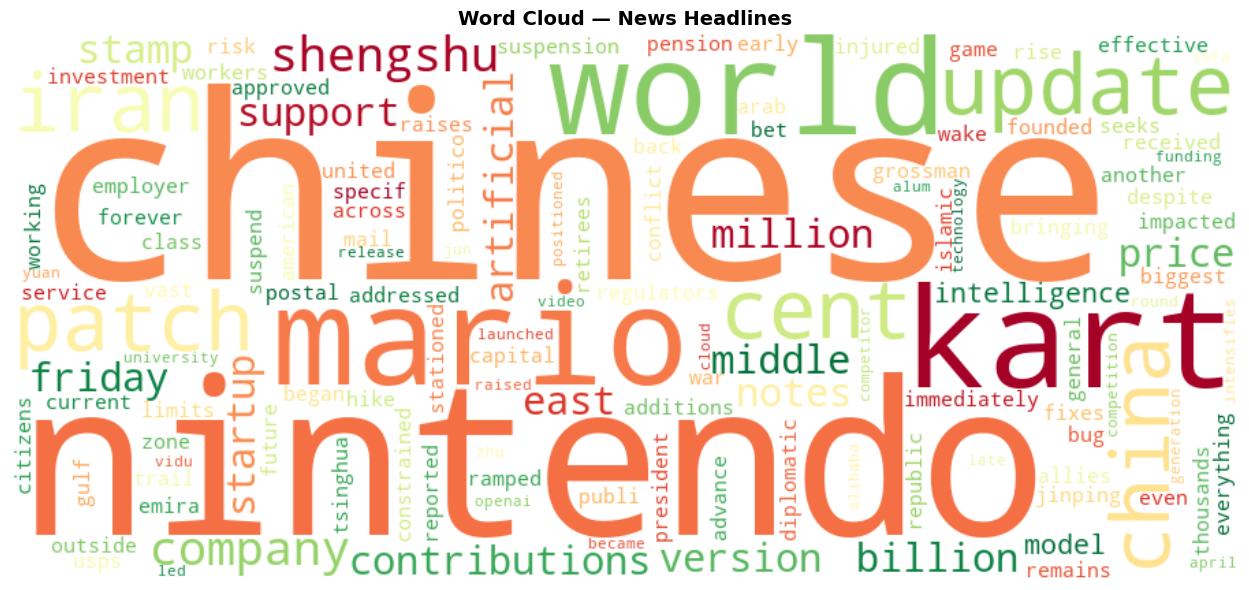

✅ Word cloud displayed


In [42]:
wc = WordCloud(
    width=900, height=400,
    background_color='white',
    colormap='RdYlGn',
    max_words=150,
    collocations=False
).generate(text_for_cloud)
 
plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud — News Headlines", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Word cloud displayed")

In [22]:
# ── Initialise VADER ─────────────────────────────────────────────
vader = SentimentIntensityAnalyzer()
 
 
def vader_sentiment(text: str) -> dict:
    """Run VADER on raw (uncleaned) text — VADER works best on original text."""
    scores = vader.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        label = "Positive"
    elif compound <= -0.05:
        label = "Negative"
    else:
        label = "Neutral"
    return {"vader_compound": compound,
            "vader_pos": scores['pos'],
            "vader_neu": scores['neu'],
            "vader_neg": scores['neg'],
            "vader_label": label}

In [23]:
def textblob_sentiment(text: str) -> dict:
    """Run TextBlob on text."""
    blob = TextBlob(text)
    pol  = blob.sentiment.polarity
    subj = blob.sentiment.subjectivity
    if pol > 0.05:     label = "Positive"
    elif pol < -0.05:  label = "Negative"
    else:              label = "Neutral"
    return {"tb_polarity": pol, "tb_subjectivity": subj, "tb_label": label}

In [24]:
# ── Apply to every headline (use title + description for best results) ─
print("Running sentiment analysis...")
vader_results  = df["clean_text"].apply(vader_sentiment).apply(pd.Series)
textblob_results = df["clean_text"].apply(textblob_sentiment).apply(pd.Series)
 
 
print(vader_results)
print(textblob_results)

Running sentiment analysis...
   vader_compound  vader_pos  vader_neu  vader_neg vader_label
0          0.0000      0.000      1.000      0.000     Neutral
1          0.3612      0.090      0.842      0.067    Positive
2         -0.5106      0.081      0.796      0.123    Negative
3          0.7717      0.091      0.909      0.000    Positive
   tb_polarity  tb_subjectivity  tb_label
0    -0.031818         0.327273   Neutral
1     0.170000         0.331667  Positive
2     0.000000         0.150000   Neutral
3    -0.130000         0.413333  Negative


In [25]:
df = pd.concat([df, vader_results, textblob_results], axis=1)

In [26]:
# Consensus label (agree → use it, disagree → call it Neutral)
def consensus_label(row):
    if row["vader_label"] == row["tb_label"]:
        return row["vader_label"]
    # If one says Neutral and other says Positive/Negative, trust the non-neutral one
    if row["vader_label"] == "Neutral": return row["tb_label"]
    if row["tb_label"]    == "Neutral": return row["vader_label"]
    return "Neutral"  # conflicting non-neutral → call it Neutral
 
df["consensus_label"] = df.apply(consensus_label, axis=1)
 
print(f"\n✅ Sentiment analysis complete on {len(df)} articles")
print("\nConsensus label distribution:")
print(df["consensus_label"].value_counts())


✅ Sentiment analysis complete on 4 articles

Consensus label distribution:
consensus_label
Neutral     2
Positive    1
Negative    1
Name: count, dtype: int64


In [27]:
# ── Show example headlines with their sentiment scores ───────────
cols = ["title", "category", "vader_compound", "tb_polarity", "tb_subjectivity", "consensus_label"]
display_df = df[cols].sort_values("vader_compound", ascending=False)
 
print("🟢 Top 5 Most POSITIVE headlines:")
for _, row in display_df.head(5).iterrows():
    print(f"  [{row['consensus_label']:8s} | score: {row['vader_compound']:+.2f}] {row['title'][:80]}")
 
print("\n🔴 Top 5 Most NEGATIVE headlines:")
for _, row in display_df.tail(5).iterrows():
    print(f"  [{row['consensus_label']:8s} | score: {row['vader_compound']:+.2f}] {row['title'][:80]}")

🟢 Top 5 Most POSITIVE headlines:
  [Neutral  | score: +0.77] Chinese startup ShengShu raises $293 million to advance artificial general intel
  [Positive | score: +0.36] USPS to suspend pension contributions, seeks 4-cent stamp price hike - Politico
  [Neutral  | score: +0.00] Mario Kart World 1.6.1 update out now, patch notes - Nintendo Everything
  [Negative | score: -0.51] Xi’s $270 Billion Middle East Bet Limits China Support for Iran

🔴 Top 5 Most NEGATIVE headlines:
  [Neutral  | score: +0.77] Chinese startup ShengShu raises $293 million to advance artificial general intel
  [Positive | score: +0.36] USPS to suspend pension contributions, seeks 4-cent stamp price hike - Politico
  [Neutral  | score: +0.00] Mario Kart World 1.6.1 update out now, patch notes - Nintendo Everything
  [Negative | score: -0.51] Xi’s $270 Billion Middle East Bet Limits China Support for Iran


In [28]:
# ── Visualize 1: Sentiment distribution by category ──────────────
COLOR_MAP = {"Positive": "#2ecc71", "Neutral": "#95a5a6", "Negative": "#e74c3c"}
 
cat_sentiment = df.groupby(["category", "consensus_label"]).size().unstack(fill_value=0)
print(cat_sentiment
      )
cat_sentiment_pct = cat_sentiment.div(cat_sentiment.sum(axis=1), axis=0) * 100

consensus_label             Negative  Neutral  Positive
category                                               
business                           0        0         1
kw:artificial intelligence         0        1         0
kw:economy                         1        0         0
technology                         0        1         0


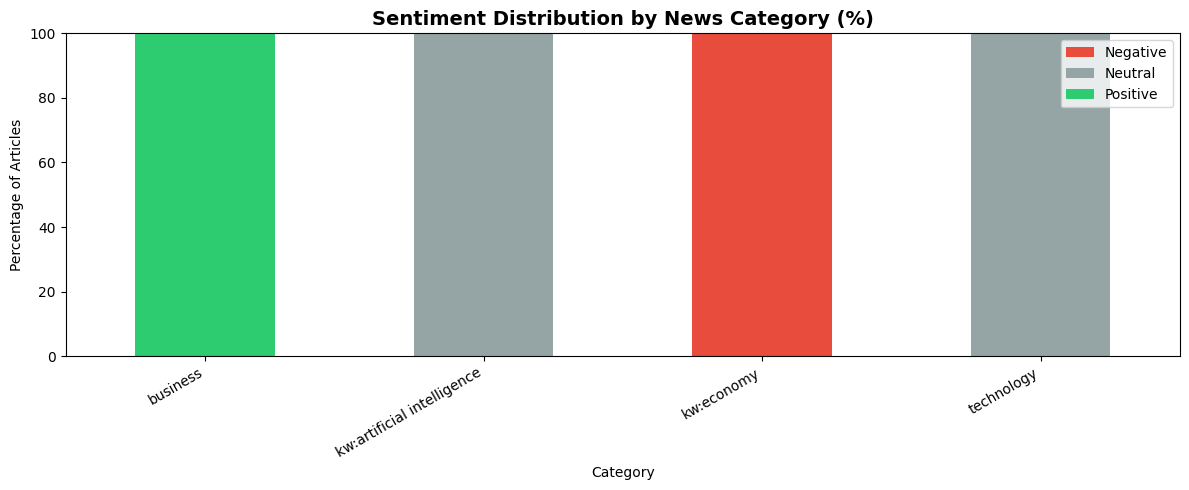

✅ Stacked bar chart displayed


In [29]:
ax = cat_sentiment_pct.plot(
    kind='bar', stacked=True, figsize=(12, 5),
    color=[COLOR_MAP.get(c, '#cccccc') for c in cat_sentiment_pct.columns]
)
plt.title("Sentiment Distribution by News Category (%)", fontsize=14, fontweight='bold')
plt.xlabel("Category")
plt.ylabel("Percentage of Articles")
plt.xticks(rotation=30, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()
print("✅ Stacked bar chart displayed")

In [30]:
HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0.0.0 Safari/537.36"
    )
}

soup <!DOCTYPE html>
<html dir="ltr" lang="en"><head><link href="https://www.indiatoday.in/manifest.json" rel="manifest"/><meta content="#C04A4A" name="theme-color"/><link href="https://www.indiatoday.in/favicon.ico" rel="shortcut icon" type="image/vnd.microsoft.icon"/><title>Iran has lost track of mines it planted in Hormuz, reopening delayed: Report - India Today</title><meta charset="utf-8"/><meta content="width=device-width, minimum-scale=1, initial-scale=1.0, maximum-scale=5.0" name="viewport"/><link href="https://akm-img-a-in.tosshub.com/indiatoday/images/misc/IT-logo-180.png" rel="apple-touch-icon"/><link href="https://www.indiatoday.in/world/story/iran-lost-track-of-mines-it-planted-in-strait-of-hormuz-us-middle-east-war-2894654-2026-04-11" rel="canonical"/><meta content="US officials said that Iran's inability to locate and remove mines it deployed is delaying safe passage through the Strait of Hormuz, even as pressure mounts to restore normal shipping traffic." name="descript
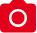

'Iran\'s inability to fully reopen the Strait of Hormuzstems from a basic problem that it cannot locate all the naval mines it deployed during the Middle East conflict and lacks the technical capability to remove them, US officials toldThe New York Times. The problem traces back to last month, when Iran began seeding the waterway with mines using small boats, soon after the United States and Israel launched their war against the Islamic nation. Even then, American officials noted the operation was neither fast nor efficient. Before any mines were placed, the disruption had already begun. On March 2, a senior Islamic Revolutionary Guards Corps official declared the strait closed andwarned that any vessel entering could be set \'ablaze\', according to state media. Shipping was rattled, and oil prices spiked across the globe. Once the mines were deployed, the impact deepened. Tanker movement dropped sharply, with the added threat of Iranian drone and missile strikes compounding the risk. 

In [33]:
def scrape_article_text(url: str, timeout: int = 8) -> str:
    """
    Scrape full article text from a given URL.
    Returns cleaned paragraph text or empty string on failure.
    """
    try:
        response = requests.get(url, headers=HEADERS, timeout=timeout)
        response.raise_for_status()                        # raise on 4xx/5xx
 
        soup = BeautifulSoup(response.text, 'html.parser')
        print('soup',soup)
        # ── Strategy 1: look for <article> tag (modern sites) ────
        article_tag = soup.find('article')
        print(article_tag, 'article_tag')
        if article_tag:
            paragraphs = article_tag.find_all('p')
        else:
            # ── Strategy 2: fall back to all <p> tags ────────────
            paragraphs = soup.find_all('p')
        print('paragraph', paragraphs)
        # Extract and join non-empty paragraph text
        text = ' '.join(
            p.get_text(strip=True)
            for p in paragraphs
            if len(p.get_text(strip=True)) > 40   # skip tiny/nav paragraphs
        )
        return text[:3000]   # cap at 3000 chars to keep things fast
 
    except Exception as e:
        return ""   # silently skip failed URLs
   
scrape_article_text('https://www.indiatoday.in/world/story/iran-lost-track-of-mines-it-planted-in-strait-of-hormuz-us-middle-east-war-2894654-2026-04-11%27')

Scraping 5 full articles...
soup <!DOCTYPE HTML>
<html class="no-js" lang="en"><head><meta charset="utf-8"/><meta content="IE=edge" http-equiv="X-UA-Compatible"/><meta content="width=device-width, initial-scale=1" name="viewport"/><meta content="text/html; charset=utf-8" http-equiv="Content-Type"><link href="https://nintendoeverything.com/wp-content/cache/autoptimize/css/autoptimize_5565801cf817a542f90ad17c31b32fd8.css" media="all" rel="stylesheet"/><title>Mario Kart World 1.6.1 update out now, patch notes</title><link crossorigin="" href="https://securepubads.g.doubleclick.net/" rel="preconnect"/><link crossorigin="" href="https://cdn.consentmanager.mgr.consensu.org/" rel="preconnect"/><link crossorigin="" href="https://live.primis.tech" rel="preconnect"/><link as="script" href="https://00917082-71e9-498e-8343-00c3df06b798.edge.permutive.app/00917082-71e9-498e-8343-00c3df06b798-web.js" rel="preload"/><link as="script" href="https://sb.scorecardresearch.com/cs/25110922/beacon.js" rel="
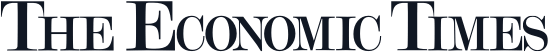

In [34]:
# ── Scrape a small sample (5 articles) to demonstrate ────────────
# (Scraping all 100+ would be slow — use a subset for the lab)
SCRAPE_SAMPLE = 5
scrape_sample = df[df["url"].str.startswith("http")].head(SCRAPE_SAMPLE).copy()
 
print(f"Scraping {SCRAPE_SAMPLE} full articles...")
scraped_texts = []
for i, (idx, row) in enumerate(scrape_sample.iterrows()):
    text = scrape_article_text(row["url"])
    word_count = len(text.split()) if text else 0
    scraped_texts.append(text)
    status = "✅" if text else "⚠️ "
    print(f"  {status} [{i+1}/{SCRAPE_SAMPLE}] {row['source']:20s} → {word_count:4d} words")
    time.sleep(1)   # be polite — 1 second between requests
 
scrape_sample["scraped_text"] = scraped_texts
print("\nDone!")
 

In [35]:
scrape_sample.head()

,title,description,source,url,published_at,category,full_text,clean_text,proper_nouns,tickers,...,vader_compound,vader_pos,vader_neu,vader_neg,vader_label,tb_polarity,tb_subjectivity,tb_label,consensus_label,scraped_text
0,"Mario Kart World 1.6.1 update out now, patch n...",Mario Kart World just received a new version 1...,Nintendoeverything.com,https://nintendoeverything.com/mario-kart-worl...,2026-04-10T01:06:45Z,technology,"Mario Kart World 1.6.1 update out now, patch n...",mario kart world update out now patch notes ni...,"[Mario Kart World, Nintendo Everything Mario K...",[],...,0.0000,0.000,1.000,0.000,Neutral,-0.031818,0.327273,Neutral,Neutral,Nintendo is back with another update for Mario...
1,"USPS to suspend pension contributions, seeks 4...","If approved by regulators, the price of a firs...",Politico,https://www.politico.com/news/2026/04/09/usps-...,2026-04-10T01:00:00Z,business,"USPS to suspend pension contributions, seeks 4...",usps to suspend pension contributions seeks ce...,"[Politico If, Postal Service]",[USPS],...,0.3612,0.090,0.842,0.067,Positive,0.170000,0.331667,Positive,Positive,
2,Xi’s $270 Billion Middle East Bet Limits China...,Even as China remains one of Iran’s biggest di...,Financial Post,https://financialpost.com/pmn/business-pmn/xis...,2026-04-10T04:58:55Z,kw:economy,Xi’s $270 Billion Middle East Bet Limits China...,xi s billion middle east bet limits china supp...,"[Billion Middle East Bet Limits China Support,...",[],...,-0.5106,0.081,0.796,0.123,Negative,0.000000,0.150000,Neutral,Negative,Even as China remains one of Iran’s biggest di...
3,Chinese startup ShengShu raises $293 million t...,Founded in early 2023 by ​Tsinghua University ...,The Times of India,https://economictimes.indiatimes.com/tech/fund...,2026-04-10T04:55:05Z,kw:artificial intelligence,Chinese startup ShengShu raises $293 million t...,chinese startup shengshu raises million to adv...,"[Tsinghua University, Zhu Jun, Alibaba Cloud]",[],...,0.7717,0.091,0.909,0.000,Positive,-0.130000,0.413333,Negative,Neutral,"(Catch all theTechnology News News, andLatest ..."


In [37]:
# ── Analyse scraped text with BeautifulSoup metadata extraction ──
def extract_page_metadata(url: str) -> dict:
    """
    Extract metadata (og:title, og:description, keywords) from a page.
    Demonstrates BeautifulSoup meta tag parsing.
    """
    try:
        response = requests.get(url, headers=HEADERS, timeout=8)
        soup = BeautifulSoup(response.text, 'html.parser')
 
        def get_meta(prop):
            tag = soup.find('meta', property=prop) or soup.find('meta', attrs={'name': prop})
            return tag['content'] if tag and tag.get('content') else None
 
        return {
            "og_title":       get_meta('og:title'),
            "og_description": get_meta('og:description'),
            "meta_keywords":  get_meta('keywords'),
            "h1_tags":        [h.get_text(strip=True) for h in soup.find_all('h1')][:3]
        }
    except Exception:
        return {}
 
 # Demo on first article
sample_url = df[df["url"].str.startswith("http")]["url"].iloc[0]
meta = extract_page_metadata(sample_url)
print("Page metadata extracted via BeautifulSoup:")
for key, val in meta.items():
    print(f"  {key:20s}: {str(val)[:80]}")

Page metadata extracted via BeautifulSoup:
  og_title            : Mario Kart World 1.6.1 update out now, patch notes
  og_description      : Mario Kart World just received a new version 1.6.1 update from Nintendo, and you
  meta_keywords       : None
  h1_tags             : ['Mario Kart World 1.6.1 update out now, patch notes']


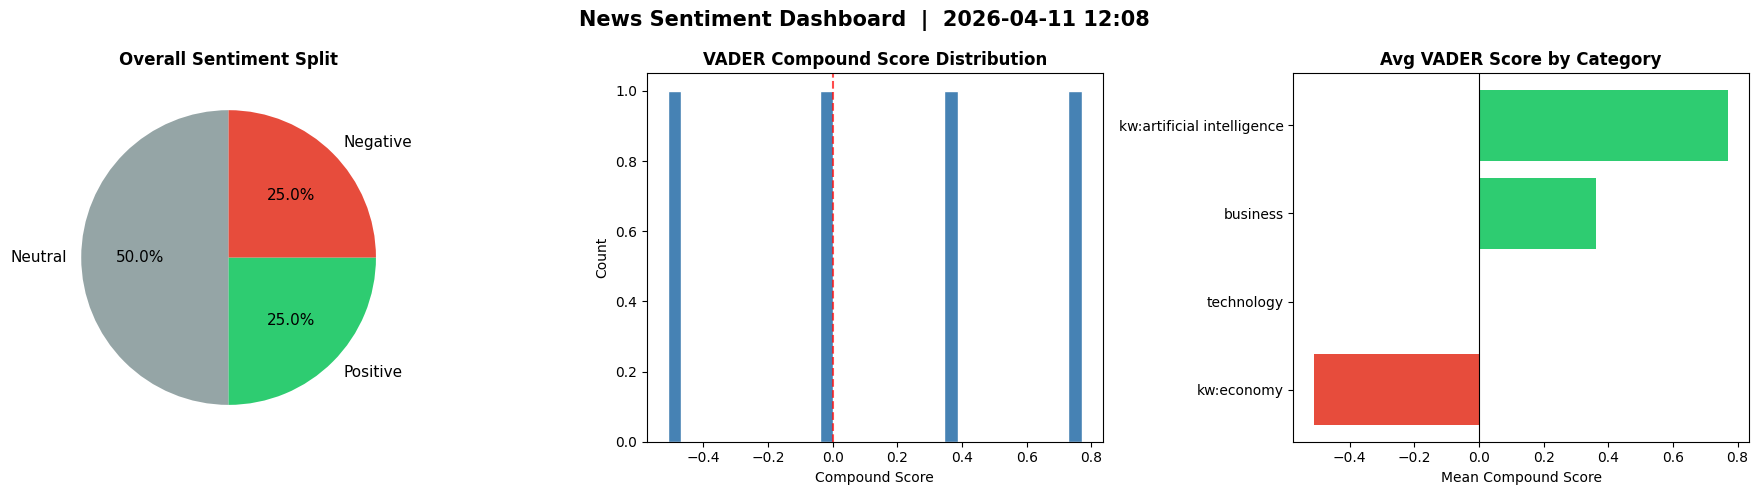

✅ Dashboard Panel 1 displayed


In [38]:
# ── Dashboard Panel 1: Sentiment Overview Pie ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"News Sentiment Dashboard  |  {datetime.now().strftime('%Y-%m-%d %H:%M')}",
             fontsize=15, fontweight='bold')
 
# Panel 1 — Overall pie
counts = df["consensus_label"].value_counts()
axes[0].pie(
    counts.values,
    labels=counts.index,
    colors=[COLOR_MAP[l] for l in counts.index],
    autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11}
)
axes[0].set_title("Overall Sentiment Split", fontweight='bold')
 
# Panel 2 — VADER compound distribution histogram
axes[1].hist(df["vader_compound"], bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.7)
axes[1].set_title("VADER Compound Score Distribution", fontweight='bold')
axes[1].set_xlabel("Compound Score")
axes[1].set_ylabel("Count")
 
# Panel 3 — Average sentiment per category
cat_avg = df.groupby('category')['vader_compound'].mean().sort_values()
colors  = ['#e74c3c' if v < 0 else '#2ecc71' for v in cat_avg.values]
axes[2].barh(cat_avg.index, cat_avg.values, color=colors)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title("Avg VADER Score by Category", fontweight='bold')
axes[2].set_xlabel("Mean Compound Score")
 
plt.tight_layout()
plt.show()
print("✅ Dashboard Panel 1 displayed")

In [39]:
# ── Export final DataFrame to CSV ────────────────────────────────
output_cols = [
    'title', 'source', 'category', 'published_at',
    'vader_compound', 'vader_label',
    'tb_polarity', 'tb_subjectivity', 'tb_label',
    'consensus_label', 'token_count', 'url'
]
df[output_cols].to_csv('news_sentiment_results.csv', index=False)
print("✅ Results saved to news_sentiment_results.csv")
print(f"   Shape: {df[output_cols].shape}")
df[output_cols].head()

✅ Results saved to news_sentiment_results.csv
   Shape: (4, 12)


,title,source,category,published_at,vader_compound,vader_label,tb_polarity,tb_subjectivity,tb_label,consensus_label,token_count,url
0,"Mario Kart World 1.6.1 update out now, patch n...",Nintendoeverything.com,technology,2026-04-10T01:06:45Z,0.0000,Neutral,-0.031818,0.327273,Neutral,Neutral,34,https://nintendoeverything.com/mario-kart-worl...
1,"USPS to suspend pension contributions, seeks 4...",Politico,business,2026-04-10T01:00:00Z,0.3612,Positive,0.170000,0.331667,Positive,Positive,37,https://www.politico.com/news/2026/04/09/usps-...
2,Xi’s $270 Billion Middle East Bet Limits China...,Financial Post,kw:economy,2026-04-10T04:58:55Z,-0.5106,Negative,0.000000,0.150000,Neutral,Negative,51,https://financialpost.com/pmn/business-pmn/xis...
3,Chinese startup ShengShu raises $293 million t...,The Times of India,kw:artificial intelligence,2026-04-10T04:55:05Z,0.7717,Positive,-0.130000,0.413333,Negative,Neutral,53,https://economictimes.indiatimes.com/tech/fund...


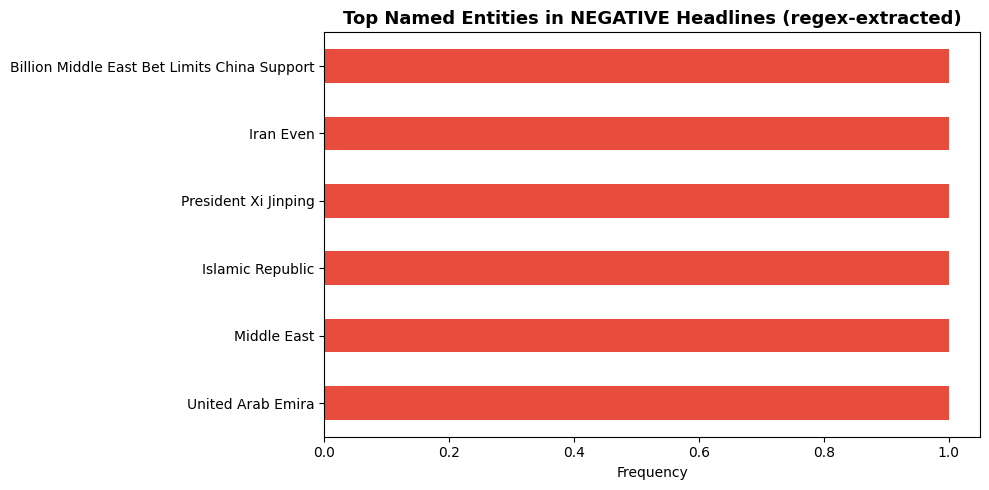

✅ Named entity chart displayed


In [40]:
# ── Dashboard Panel 3: Named entity frequency in negative news ───
negative_articles = df[df["consensus_label"] == "Negative"]
neg_entities = [e for entities in negative_articles["proper_nouns"] for e in entities]
 
if neg_entities:
    neg_freq = pd.Series(neg_entities).value_counts().head(20)
 
    plt.figure(figsize=(10, 5))
    neg_freq.plot(kind='barh', color='#e74c3c')
    plt.title("Top Named Entities in NEGATIVE Headlines (regex-extracted)",
              fontsize=13, fontweight='bold')
    plt.xlabel("Frequency")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    print("✅ Named entity chart displayed")
else:
    print("No named entities found in negative articles (check your data).")